# DESENVOLVIMENTO DA INICIAÇÃO CIENTÍFICA 

# BASE DE DADOS DE 2025

# Preparação do ambientes

In [ ]:
pip install  matplotlib numpy pandas seaborn scikit-learn seaborn

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

# Carregamento da base de dados

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/EduardoMiranda06/ANALISE-EXPERIMENTAL-COM-CILINDROS-DE-PLA-COM-INTEGRACAO-DE-INTELIGENCIA-ARTIFICIAL-IC/refs/heads/main/2025/dados2025.csv')


# Padronização da base

In [3]:
df.columns = [                               # Reatribui explicitamente os nomes das colunas para padronizar o DataFrame e evitar problemas com acentos, espaços ou unidades nos nomes
    "ID",                                    # Identificador único de cada amostra, permite rastreabilidade e extração posterior dos IDs suspeitos
    "diametro",                              # Diâmetro do cilindro em mm, variável geométrica usada no cálculo de área, volume e densidade aparente
    "altura",                                # Altura do cilindro em mm, complementa o diâmetro no cálculo do volume do cilindro
    "massa",                                 # Massa da amostra em gramas, utilizada em análises físicas e na normalização da resistência
    "resistencia",                           # Valor de carga máxima no ensaio mecânico, principal variável de interesse do projeto
    "recozido"                               # Variável categórica que indica a aplicação do tratamento térmico, essencial para comparar grupos experimentais
]                                            

# Padronização dos nomes facilita chamadas diretas nas análises estatísticas, regressões e modelos de aprendizado de máquina

# Primeiras visualizações e inspeções de dados

In [4]:
df.head() # Visualiza as primeiras linhas

,ID,diametro,altura,massa,resistencia,recozido
0,335,17.38,32.80,8.2,1225,NÃO
1,297,14.71,20.43,3.8,958,NÃO
2,318,15.85,21.84,4.7,1129,NÃO
3,311,15.16,28.32,5.5,988,NÃO
4,315,15.86,21.82,4.7,1113,NÃO


In [5]:
df.info() # Informações gerais sobre tipos de dados e valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           107 non-null    int64  
 1   diametro     107 non-null    float64
 2   altura       107 non-null    float64
 3   massa        107 non-null    float64
 4   resistencia  107 non-null    object 
 5   recozido     107 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 5.1+ KB


In [6]:
df.describe(include="all") # Estatísticas descritivas iniciais

,ID,diametro,altura,massa,resistencia,recozido
count,107.000000,107.000000,107.000000,107.000000,107,107
unique,NaN,NaN,NaN,NaN,93,2
top,NaN,NaN,NaN,NaN,FALHA,NÃO
freq,NaN,NaN,NaN,NaN,10,75
mean,339.448598,14.819346,24.566449,4.381121,NaN,NaN
std,53.370233,1.557224,3.797461,2.064734,NaN,NaN
min,270.000000,12.330000,17.150000,0.000000,NaN,NaN
25%,296.500000,13.395000,21.855000,3.250000,NaN,NaN
50%,323.000000,14.740000,24.410000,4.600000,NaN,NaN
75%,404.500000,15.900000,27.445000,5.800000,NaN,NaN


In [7]:
df["recozido"].value_counts() # Frequência da variável Recozidos

recozido
NÃO    75
SIM    32
Name: count, dtype: int64

In [8]:
df["resistencia"].astype(str).value_counts() # Frequência de valores inválidos na resistência

resistencia
FALHA    10
787       2
814       2
1227      2
896       2
         ..
1242      1
1365      1
1339      1
1300      1
1329      1
Name: count, Length: 93, dtype: int64

# Tratamento de valores inválidos e inconsistências

In [9]:
df["falha_ensaio"] = df["resistencia"].astype(str).str.upper().eq("FALHA").astype(int) # Identifica falha total no ensaio

df["resistencia"] = pd.to_numeric(df["resistencia"], errors="coerce") # Converte resistência para numérico

df.loc[df["massa"] == 0, "massa"] = np.nan # Massa igual a zero não é fisicamente válida

df["recozido"] = df["recozido"].map({"SIM": 1, "NÃO": 0}) # Converte recozimento para variável binária

# Engenharia de atributos

In [10]:
df["area_secao"] = np.pi * (df["diametro"] / 2) ** 2 # Área da seção transversal do cilindro

df["volume"] = df["area_secao"] * df["altura"] # Volume do cilindro

df["densidade_aparente"] = df["massa"] / df["volume"] # Densidade aparente

df["resistencia_especifica"] = df["resistencia"] / df["massa"] # Resistência específica

# Base válida para análises mecânicas contínuas

In [11]:
df_validos = df[                             # Cria um novo DataFrame filtrando apenas as amostras consideradas válidas para análises quantitativas
    (df["falha_ensaio"] == 0) &              # Mantém apenas amostras que não apresentaram falha total no ensaio mecânico
    (df["massa"].notna()) &                  # Remove amostras com massa ausente (NaN), evitando inconsistências físicas e divisões inválidas
    (df["resistencia"].notna())              # Remove amostras sem valor numérico de resistência, garantindo integridade estatística
].copy()                                     # Gera uma cópia independente para evitar efeitos colaterais (SettingWithCopyWarning) nas etapas seguintes
                                             
                                             
# Este subconjunto representa apenas amostras fisicamente coerentes e mensuráveis, sendo a base para regressões, correlações, análise de resíduos e modelos supervisionados

# Análise exploratória comparativa (Recozido vs Não recozido)

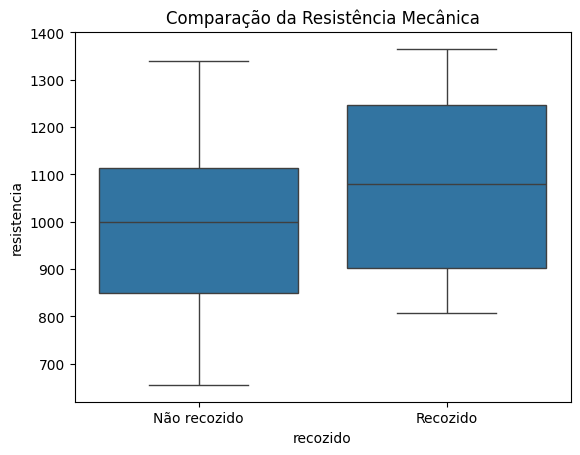

In [12]:
sns.boxplot(                                     # Cria um boxplot para comparar distribuições de uma variável numérica entre grupos categóricos
    x="recozido",                                # Define a variável categórica que separa os grupos experimentais (0 = não recozido, 1 = recozido)
    y="resistencia",                             # Define a variável numérica analisada, representando a resistência mecânica das amostras
    data=df_validos                              # Utiliza apenas amostras válidas, sem falhas totais ou valores ausentes
)
plt.xticks([0, 1],                               # Ajusta manualmente as posições dos rótulos do eixo x para corresponder aos valores binários
           ["Não recozido", "Recozido"])         # Substitui 0 e 1 por rótulos interpretáveis, melhorando clareza visual e leitura científica
plt.title("Comparação da Resistência Mecânica")  # Define o título do gráfico, contextualizando a análise comparativa entre os grupos
plt.show()                                       # Renderiza o gráfico no notebook, permitindo inspeção visual imediata
                                            
                                            
# O boxplot permite avaliar diferenças de mediana, dispersão e presença de outliers entre recozidos e não recozidos, sendo fundamental para observar visualmente o efeito do tratamento térmico

# Regressão linear e análise de resíduos

In [13]:
coef = np.polyfit(                          # Ajusta um polinômio aos dados usando mínimos quadrados (regressão linear simples)
    df_validos["massa"],                    # Variável independente (x), representando a massa das amostras
    df_validos["resistencia"],              # Variável dependente (y), representando a resistência mecânica medida
    1                                       # Grau do polinômio igual a 1, resultando em uma regressão linear (reta)
)                                           # Retorna os coeficientes da reta no formato [inclinação, intercepto]

df_validos["resistencia_prevista"] = np.polyval(  # Calcula os valores previstos pela regressão linear para cada amostra
    coef,                                   # Coeficientes calculados pelo polyfit (inclinação e intercepto)
    df_validos["massa"]                     # Valores de massa usados para estimar a resistência correspondente
)                                           # Gera a tendência média esperada da resistência em função da massa

df_validos["residuo"] = (                   # Calcula o resíduo da regressão para cada amostra
    df_validos["resistencia"] -             # Valor real de resistência medido experimentalmente
    df_validos["resistencia_prevista"]      # Valor previsto pelo modelo linear
)                                           # Resíduos negativos indicam amostras mais fracas que o esperado; positivos, mais resistentes
                                            
                                            
# A análise de resíduos permite isolar variações estruturais não explicadas pela massa, sendo crucial para detectar defeitos internos e outliers físicos independentemente do tamanho da amostra

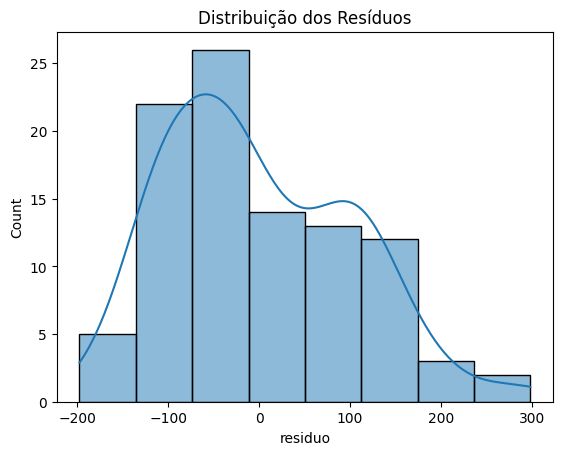

In [14]:
sns.histplot(                               # Cria um histograma para visualizar a distribuição de uma variável numérica
    df_validos["residuo"],                  # Utiliza os resíduos da regressão, que representam o desvio entre valor real e previsto
    kde=True                                # Adiciona a curva de densidade (Kernel Density Estimation) para suavizar e interpretar a forma da distribuição
)
plt.title("Distribuição dos Resíduos")      # Define o título do gráfico, indicando que a análise é baseada nos resíduos da regressão
plt.show()                                 # Renderiza o gráfico no notebook para inspeção visual
                                            
                                            
# A distribuição dos resíduos permite verificar simetria, dispersão e caudas extremas, auxiliando na identificação de anomalias estruturais e na validação da adequação do modelo linear

# Defeito por critério estatístico

In [15]:
limiar = df_validos["resistencia"].quantile(0.20) # Definimos um limiar de resistência baseado no percentil 20

df_validos["defeito_estatistico"] = (
    df_validos["resistencia"] < limiar
).astype(int)

# Criamos a variável 'defeito_estatistico'|  1 para peças com resistência abaixo do limiar e  0 para peças consideradas normais

# Detecção de anomalias com Isolation Forest

In [16]:
features_if = [                             # Define a lista de variáveis que serão usadas como entrada no modelo de detecção de anomalias
    "massa",                                # Massa da amostra, representa escala física e influencia propriedades mecânicas
    "densidade_aparente",                   # Relação massa/volume, sensível a vazios internos e defeitos estruturais
    "resistencia_especifica"                # Resistência normalizada pela massa, reduz viés geométrico e destaca falhas internas
]

X_if = df_validos[features_if].fillna(      # Seleciona apenas as features definidas e trata valores ausentes
    df_validos[features_if].median()        # Substitui NaNs pela mediana de cada variável, método robusto a outliers
)                                           # Garante matriz numérica completa para o algoritmo Isolation Forest

iso = IsolationForest(                      # Inicializa o modelo de detecção de anomalias baseado em isolamento de observações
    contamination=0.15,                     # Define a fração esperada de anomalias no conjunto (15%), refletindo presença de defeitos
    random_state=42                         # Fixa a semente aleatória para reprodutibilidade dos resultados
)

df_validos["anomalia"] = iso.fit_predict(X_if)  # Ajusta o modelo aos dados e classifica cada amostra como normal (1) ou anômala (-1)
df_validos["anomalia"] = df_validos["anomalia"].map({1: 0, -1: 1})  # Converte a saída para formato binário interpretável (0 = normal, 1 = anomalia)
                                            
                                            
# O Isolation Forest identifica amostras com comportamento físico atípico sem usar rótulos, sendo essencial para detectar defeitos internos invisíveis externamente

# Integração dos critérios de defeito

In [17]:
df_validos["defeito"] = np.where(            # Cria a variável final de defeito combinando múltiplos critérios de detecção
    (df_validos["defeito_estatistico"] == 1) |  # Marca como defeito amostras identificadas por critério estatístico (ex: limiar de resistência ou resíduos extremos)
    (df_validos["anomalia"] == 1),           # Marca como defeito amostras classificadas como anômalas pelo Isolation Forest
    1,                                       # Atribui valor 1 quando qualquer um dos critérios indica defeito
    0                                        # Atribui valor 0 quando a amostra é considerada normal por ambos os critérios
)                                            # Implementa uma regra lógica OR para aumentar sensibilidade na detecção de defeitos
                                            
                                            
# A integração de critérios estatísticos e não supervisionados reduz falsos negativos e gera um rótulo robusto para etapas supervisionadas e geração da lista final de IDs suspeitos

# Base final para aprendizado supervisionado

In [18]:
df_falhas = df[df["falha_ensaio"] == 1].copy()   # Cria um DataFrame separado contendo apenas amostras que apresentaram falha total no ensaio mecânico
df_falhas["defeito"] = 1                        # Rotula explicitamente essas amostras como defeituosas, pois a falha no ensaio indica defeito estrutural severo

df_ml = pd.concat([df_validos, df_falhas], axis=0)  # Combina amostras válidas e falhas totais em um único DataFrame para aprendizado supervisionado

features_ml = [                                 # Define o conjunto de variáveis explicativas usadas nos modelos supervisionados
    "diametro",                                # Variável geométrica que influencia volume e distribuição de tensões
    "altura",                                  # Variável geométrica complementar ao diâmetro
    "massa",                                   # Massa da amostra, relacionada à densidade e integridade estrutural
    "densidade_aparente",                      # Métrica física sensível à presença de vazios internos
    "recozido"                                 # Indica aplicação do tratamento térmico, permitindo ao modelo aprender seu efeito
]

X = df_ml[features_ml].fillna(                  # Seleciona as features e trata valores ausentes antes do treinamento
    df_ml[features_ml].median()                 # Substitui NaNs pela mediana, método robusto e adequado para dados experimentais
)                                               # Garante uma matriz numérica completa para os algoritmos de ML

y = df_ml["defeito"]                            # Define a variável alvo, onde 1 indica defeito estrutural e 0 indica amostra considerada normal
                                                
                                                
# Este bloco prepara o dataset final para aprendizado supervisionado, integrando falhas reais e defeitos inferidos, permitindo treinar modelos capazes de prever defeitos internos em novas amostras

# Modelos supervisionados

In [19]:
X_train, X_test, y_train, y_test = train_test_split(  # Divide o conjunto de dados em subconjuntos de treino e teste
    X,                                                  # Matriz de variáveis explicativas (features) usada pelos modelos supervisionados
    y,                                                  # Vetor da variável alvo, indicando presença ou ausência de defeito
    test_size=0.3,                                     # Reserva 30% dos dados para teste, permitindo avaliar a generalização do modelo
    random_state=42                                    # Fixa a semente aleatória para garantir reprodutibilidade da divisão
)                                                      # Retorna conjuntos separados para treinamento e validação do modelo
                                                      
                                                      
# A separação treino/teste evita overfitting e permite avaliar o desempenho do modelo em dados não vistos, prática essencial em aprendizado de máquina aplicado

In [20]:
svm = SVC()                                   # Inicializa o classificador Support Vector Machine, adequado para problemas de classificação com fronteiras não lineares
svm.fit(X_train, y_train)                    # Ajusta o modelo aos dados de treino, aprendendo a separar amostras defeituosas e não defeituosas

y_pred = svm.predict(X_test)                 # Utiliza o modelo treinado para prever a classe das amostras do conjunto de teste
print("SVM")                                 # Identifica no output qual modelo está sendo avaliado
print(classification_report(y_test, y_pred)) # Exibe métricas como precisão, recall, f1-score e suporte para cada classe
                                            
                                            
# O relatório de classificação permite avaliar a capacidade do SVM em identificar defeitos, sendo o recall da classe defeito uma métrica crítica neste contexto experimental

SVM
              precision    recall  f1-score   support

           0       0.58      1.00      0.73        19
           1       0.00      0.00      0.00        14

    accuracy                           0.58        33
   macro avg       0.29      0.50      0.37        33
weighted avg       0.33      0.58      0.42        33



c:\Users\edumi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\edumi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\edumi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [21]:
dt = DecisionTreeClassifier(                 # Inicializa o classificador de Árvore de Decisão, modelo interpretável baseado em regras hierárquicas
    max_depth=4,                             # Limita a profundidade da árvore para reduzir overfitting e manter regras mais gerais
    random_state=42                          # Fixa a semente aleatória para garantir reprodutibilidade do treinamento
)
dt.fit(X_train, y_train)                     # Treina o modelo aprendendo regras de decisão a partir das features e rótulos de defeito

y_pred_dt = dt.predict(X_test)               # Realiza a predição das classes para o conjunto de teste
print("Árvore de Decisão")                   # Identifica no output qual modelo está sendo avaliado
print(classification_report(y_test, y_pred_dt))  # Exibe métricas de desempenho para cada classe prevista
                                            
                                            
# A árvore de decisão permite interpretar quais variáveis físicas mais influenciam a identificação de defeitos, sendo valiosa para análise técnica e validação experimental

Árvore de Decisão
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.86      0.86      0.86        14

    accuracy                           0.88        33
   macro avg       0.88      0.88      0.88        33
weighted avg       0.88      0.88      0.88        33



# Identificação e exportação dos IDs suspeitos

In [22]:
df_ml["suspeito"] = np.where(df_ml["defeito"] == 1, 1, 0) # Define que uma peça é suspeita se: falhou no ensaio ou foi detectada como anomalia

ids_suspeitos = df_ml[df_ml["suspeito"] == 1]["ID"]
ids_suspeitos

# Explicação : Filtramos apenas peças suspeitas,selecionamos a coluna ID para que o resultado seja direto para rastreabilidade industrial

0      335
7      284
8      338
11     287
12     278
13     283
14     282
16     344
17     270
21     340
22     271
23     285
26     274
27     281
30     319
32     304
34     272
36     273
41     343
42     286
48     276
49     277
53     280
55     292
69     400
70     401
72     403
73     404
77     408
78     409
80     411
97     275
98     279
99     288
100    289
101    298
102    412
103    413
104    414
105    415
106    300
Name: ID, dtype: int64

In [ ]:
df_ml[df_ml["suspeito"] == 1].to_csv(
    "ids_suspeitos_PLA_2025.csv",
    index=False
)

# Explicação : Gera um arquivo pronto com os objetivos -> controle de qualidade e relatório técnico 